In [1]:
import pandas as pd
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import timedelta

In [2]:
# ========================
# 1. 設定路徑 (請在此填寫您的資料夾名稱)
# ========================
from pathlib import Path

DATA_FOLDER_NAME = "data3"  # <--- 修改這裡即可切換不同資料夾
BASE_DIR = Path("C:/Users/AW'z/Downloads/ballet_Analysis_Results/260309/")
folder = BASE_DIR / DATA_FOLDER_NAME

files = {
    "stability":        folder / "stability.csv",
    "energy":           folder / "energy.csv",
    "synchronization":  folder / "synchronization.csv",
    "transition":       folder / "transition.csv",
    "stability_vectors":folder / "stability_vectors.csv",
    "geometry":         folder / "geometry.csv",
    "angular_vel":      folder / "limb_angular_velocities.csv",
    "unit_vectors":     folder / "limb_unit_vectors.csv",
}

culture_file = BASE_DIR / "ballet_cultural_library.json"
print(f"[Config] 目前讀取路徑: {folder}")


[Config] 目前讀取路徑: C:\Users\AW'z\Downloads\ballet_Analysis_Results\260309\data3


In [3]:
# ========================
# 2. 讀取所有資料
# ========================
dfs = {}
for name, path in files.items():
    if path.exists():
        dfs[name] = pd.read_csv(path)
        print(f"{name:18} 讀取成功，行數：{len(dfs[name])}")
    else:
        print(f"找不到檔案：{path}")

# 讀取文化庫
with open(culture_file, encoding="utf-8") as f:
    culture_lib = json.load(f)
print(f"文化庫載入成功，共 {len(culture_lib)} 個元素")

stability          讀取成功，行數：225
energy             讀取成功，行數：225
synchronization    讀取成功，行數：225
transition         讀取成功，行數：225
stability_vectors  讀取成功，行數：225
geometry           讀取成功，行數：225
angular_vel        讀取成功，行數：225
unit_vectors       讀取成功，行數：225
文化庫載入成功，共 110 個元素


In [4]:
# ========================
# 3. 基本前處理與時間軸統一
# ========================
# 假設所有檔案都有 Frame 和 Timestamp 欄位，以 stability.csv 為基準
base_df = dfs["stability"][["Frame", "Timestamp"]].copy()

# 合併主要指標（挑選代表性欄位）
merged = base_df.copy()

# stability
merged = merged.merge(
    dfs["stability"][["Frame", "height", "sway"]],
    on="Frame", how="left"
)

# energy
merged = merged.merge(
    dfs["energy"][["Frame", "energy"]],
    on="Frame", how="left"
)

# synchronization
merged = merged.merge(
    dfs["synchronization"][["Frame", "left", "right", "correlation"]],
    on="Frame", how="left"
)

# transition (torque, jerk)
merged = merged.merge(
    dfs["transition"][["Frame", "torque", "jerk"]],
    on="Frame", how="left"
)

# geometry
merged = merged.merge(
    dfs["geometry"][["Frame", "volume", "curvature"]],
    on="Frame", how="left"
)

print("合併後資料行數：", len(merged))
print(merged.head(3))

合併後資料行數： 225
   Frame  Timestamp    height      sway    energy      left     right  \
0      0   0.000000  0.845286  0.000000  0.000000  0.000000  0.000000   
1      1   0.033333  0.845286  0.000000  1.068631  3.570264  4.241019   
2      2   0.066667  0.845286  0.125095  0.858262  2.065952  5.206339   

   correlation    torque          jerk    volume  curvature  
0          0.0  0.000000      0.000000  0.000000   0.000000  
1          0.0  0.000000      0.000000  0.000000   0.000000  
2          0.0  7.442195  45194.367569  0.038013   7.743919  


In [5]:
# ========================
# 4. 動態階段偵測 (Autonomous Stage Detection)
# ========================
import numpy as np
from scipy.signal import find_peaks

print("正在根據能量數據自動偵測動作階段...")

# 使用平滑後的能量數據找尋峰值
energy_signal = merged['energy'].values
window_size = 5
smoothed_energy = np.convolve(energy_signal, np.ones(window_size)/window_size, mode='same')

# 找尋前 4 個顯著峰值，最小間隔 1.0 秒 (30 frames)
peaks, _ = find_peaks(smoothed_energy, distance=30, prominence=5)
peak_indices = sorted(peaks, key=lambda x: smoothed_energy[x], reverse=True)[:4]
peak_indices.sort()

lma_terms = [
    {"name": "起始位能 (Bound/Stillness)", "color": "lightblue"},
    {"name": "力流轉移 (Weight Shift/Glide)", "color": "lightgreen"},
    {"name": "衝力爆發 (Kinetic Effort/Punch)", "color": "salmon"},
    {"name": "能量收斂 (Flow Release/Stillness)", "color": "lavender"}
]

stages = []
for i, peak_idx in enumerate(peak_indices):
    if i >= len(lma_terms): break
    
    peak_time = merged.iloc[peak_idx]['Timestamp']
    # 定義區間：峰值前後各 0.5 秒
    start_t = max(0, peak_time - 0.7)
    end_t = min(merged['Timestamp'].max(), peak_time + 0.3)
    
    stages.append({
        "name": lma_terms[i]['name'],
        "start_sec": round(start_t, 2),
        "end_sec": round(end_t, 2),
        "color": lma_terms[i]['color'],
        "peak_time": round(peak_time, 2)
    })

# 如果沒偵測到足夠峰值，補足預設值
if not stages:
    print("Warning: 未偵測到顯著能量峰值，使用預設時間區間。")
    stages = [
        {"name": "起始位能", "start_sec": 0.0, "end_sec": 1.0, "color": "lightblue"}
    ]

for st in stages:
    print(f" - 偵測到階段: {st['name']} (約 {st.get('peak_time', 'N/A')}s 處)")
    st["start_frame"] = int(st["start_sec"] * 30)
    st["end_frame"]   = int(st["end_sec"]   * 30)


正在根據能量數據自動偵測動作階段...
 - 偵測到階段: 起始位能 (Bound/Stillness) (約 1.5s 處)
 - 偵測到階段: 力流轉移 (Weight Shift/Glide) (約 3.63s 處)
 - 偵測到階段: 衝力爆發 (Kinetic Effort/Punch) (約 5.03s 處)
 - 偵測到階段: 能量收斂 (Flow Release/Stillness) (約 6.3s 處)


In [6]:
# ========================
# 5. 每個階段計算代表性統計
# ========================
stage_stats = []

for st in stages:
    mask = (merged["Timestamp"] >= st["start_sec"]) & (merged["Timestamp"] <= st["end_sec"])
    sub = merged[mask]
    if len(sub) == 0:
        continue
    
    stats = {
        "stage": st["name"],
        "duration_sec": sub["Timestamp"].max() - sub["Timestamp"].min(),
        "energy_mean":   sub["energy"].mean(),
        "energy_max":    sub["energy"].max(),
        "sway_max":      sub["sway"].max(),
        "height_min":    sub["height"].min(),
        "jerk_max":      sub["jerk"].max(),
        "correlation_mean": sub["correlation"].mean(),
        "volume_mean":   sub["volume"].mean(),
    }
    stage_stats.append(stats)

stage_df = pd.DataFrame(stage_stats)
display(stage_df.round(3))

,stage,duration_sec,energy_mean,energy_max,sway_max,height_min,jerk_max,correlation_mean,volume_mean
0,起始位能 (Bound/Stillness),1.000,9.016,21.890,0.077,0.745,231842.416,0.571,0.083
1,力流轉移 (Weight Shift/Glide),0.967,16.447,73.095,0.188,0.791,820127.216,0.550,0.059
2,衝力爆發 (Kinetic Effort/Punch),0.967,21.352,43.447,0.224,0.732,507027.611,-0.075,0.031
3,能量收斂 (Flow Release/Stillness),1.000,13.127,114.773,0.337,0.832,5118812.523,0.024,0.080


In [7]:
# ========================
# 6. LLM API 整合：生成更自然與專業的描述
# ========================
import os
from openai import OpenAI

OPENAI_API_KEY = "sk-..."
client = OpenAI(api_key=OPENAI_API_KEY)

def llm_generate_analysis(stats, culture_info, stage_meta):
    prompt = f"""
    作為一位資深的芭蕾舞評論家與 AI 數據分析師，請分析這段效能表現。
    目前分析的是從 {stage_meta['start_sec']}s 到 {stage_meta['end_sec']}s 的區間，
    這段動態的高峰發生在約 {stage_meta.get('peak_time', 'N/A')}s。

    第一段【AI Sees】: 解析物理數據帶來的視覺震撼。
    第二段【AI Says】: 從藝術層面給予詩意的評價。

    數據統計 ({stats['stage']}):
    - 持續時間: {stats['duration_sec']:.2f} 秒
    - 平均能量: {stats['energy_mean']:.2f} (最高值 {stats['energy_max']:.2f})
    - 晃動程度: {stats['sway_max']:.3f} (Sway)
    - 肌肉控制力(Jerk): {stats['jerk_max']/1000:.0f}k

    相關文化背景參考:
    {culture_info}

    請使用繁體中文，避免生硬數據羅列。
    """
    
    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "你是一位專精於芭蕾舞藝術與運動科學的 AI 分析師。"},
                {"role": "user", "content": prompt}
            ],
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"【API Error】: {str(e)}"

for idx, st in enumerate(stages):
    stats = stage_df.iloc[idx]
    culture_suggestions = [item['description'] for item in culture_lib if any(k in item['description'] for k in [st['name'][:2]])]
    culture_info = "\n".join(culture_suggestions[:2])
    
    print(f"\n正在分析階段『{st['name']}』({st['start_sec']}s - {st['end_sec']}s)...")
    analysis_text = llm_generate_analysis(stats, culture_info, st)
    st['analysis_text'] = analysis_text
    
    print(f"\n{'═'*80}\n階段：{st['name']}\n{'─'*80}\n{analysis_text}\n{'═'*80}\n")



正在分析階段『起始位能 (Bound/Stillness)』(0.8s - 1.8s)...

════════════════════════════════════════════════════════════════════════════════
階段：起始位能 (Bound/Stillness)
────────────────────────────────────────────────────────────────────────────────
### AI Sees

在這段從0.8秒到1.8秒的區間中，舞者展現了一段精妙絕倫的力量與優雅的結合。起始時，舞者的能量水平為9.02，透露出一種沉穩的力量，並在1.5秒的高峰時達到21.89，這表明舞者在短時間內爆發出極強的能量，帶來視覺上的強烈震撼。晃動程度為0.077，顯示出舞者在運動中的穩定性與流暢度。肌肉控制力達到232k，這是一個令人驚歎的數字，顯示出舞者對自身身體的絕佳掌控力，能夠在瞬間精確地調整姿態和動作。

### AI Says

從藝術層面來看，這段表現如同一幅精緻的畫作，瞬間的爆發力猶如夜空中乍現的流星，短暫卻讓人無法忽視。舞者在穩定與動態之間找到了完美的平衡，宛如在微風中搖曳的花瓣，輕盈而不失力度。整體動作流暢而具有詩意，彷彿一首優美的詩章，帶領觀眾進入一個充滿韻律與美感的世界。在這一瞬間，舞者不僅展現了對技術的掌控，更用身體講述了一個深刻而動人心弦的故事。
════════════════════════════════════════════════════════════════════════════════


正在分析階段『力流轉移 (Weight Shift/Glide)』(2.93s - 3.93s)...

════════════════════════════════════════════════════════════════════════════════
階段：力流轉移 (Weight Shift/Glide)
────────────────────────────────────────────────────────────────────────────────
### AI Sees

在這段持續約 0.97 秒的動態中，舞者展現了卓

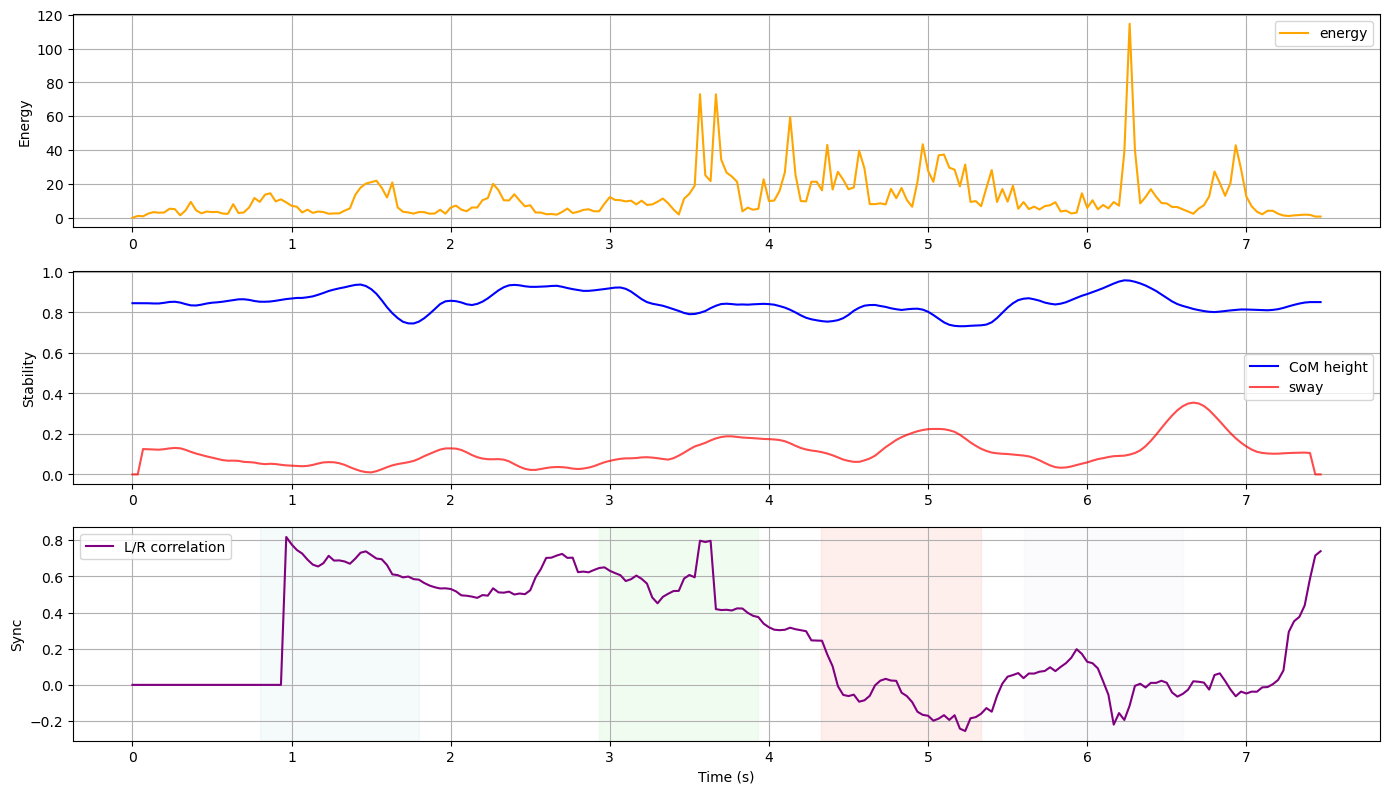

In [8]:
# 可選：畫圖觀察整體趨勢
plt.figure(figsize=(14,8))

plt.subplot(3,1,1)
plt.plot(merged["Timestamp"], merged["energy"], label="energy", color="orange")
plt.legend(); plt.ylabel("Energy"); plt.grid(True)

plt.subplot(3,1,2)
plt.plot(merged["Timestamp"], merged["height"], label="CoM height", color="blue")
plt.plot(merged["Timestamp"], merged["sway"], label="sway", color="red", alpha=0.7)
plt.legend(); plt.ylabel("Stability"); plt.grid(True)

plt.subplot(3,1,3)
plt.plot(merged["Timestamp"], merged["correlation"], label="L/R correlation", color="purple")
plt.legend(); plt.ylabel("Sync"); plt.xlabel("Time (s)"); plt.grid(True)

for st in stages:
    plt.axvspan(st["start_sec"], st["end_sec"], alpha=0.12, color=st["color"], label=st["name"])

plt.tight_layout()
plt.show()

In [9]:
# ========================
# 7. 匯出結果：儲存 AI 評論與圖片 (With Unique Filenames)
# ========================
import json
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("./output")
output_dir.mkdir(parents=True, exist_ok=True)

# 1. 儲存 AI 評論為 JSON (包含資料夾名稱以免覆蓋)
final_report = []
for st in stages:
    full_text = st.get('analysis_text', "無分析內容")
    sees_content = ""
    says_content = ""
    # 拆分 AI Sees 與 AI Says
    if "### AI Sees" in full_text:
        parts = full_text.split("### AI Says")
        sees_content = parts[0].replace("### AI Sees:", "").replace("### AI Sees", "").strip()
        if len(parts) > 1:
            says_content = parts[1].strip()
    
    final_report.append({
        "stage_name": st['name'],
        "timing": f"{st['start_sec']}s - {st['end_sec']}s",
        "full_analysis": full_text,
        "ai_sees": sees_content,
        "ai_says": says_content
    })

json_filename = f"report_{DATA_FOLDER_NAME}.json"
with open(output_dir / json_filename, "w", encoding="utf-8") as f:
    json.dump(final_report, f, ensure_ascii=False, indent=4)
print(f"[Success] JSON 報告已儲存: {json_filename}")

# 2. 儲存圖片：為每個階段產生獨立特寫
print(f"開始儲存資料夾 {DATA_FOLDER_NAME} 的各階段分析圖...")
for idx, st in enumerate(stages):
    plt.figure(figsize=(10, 5))
    padding = 0.5
    start_plot = max(0, st['start_sec'] - padding)
    end_plot = min(merged['Timestamp'].max(), st['end_sec'] + padding)
    
    mask = (merged['Timestamp'] >= start_plot) & (merged['Timestamp'] <= end_plot)
    sub_data = merged[mask]
    
    plt.plot(sub_data['Timestamp'], sub_data['energy'], label='Kinetic Energy', color='#1f77b4', linewidth=2)
    plt.fill_between(sub_data['Timestamp'], sub_data['energy'], color='#1f77b4', alpha=0.1)
    plt.axvspan(st['start_sec'], st['end_sec'], color=st['color'], alpha=0.3, label=f"Current: {st['name']}")
    
    safe_name = st['name'].replace("/", "_").replace(" ", "_")
    plt.title(f"Stage {idx+1} ({DATA_FOLDER_NAME}): {st['name']}", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 檔名包含資料夾名稱區分
    img_filename = f"stage_{idx+1}_{DATA_FOLDER_NAME}_{safe_name}.png"
    plt.savefig(output_dir / img_filename, dpi=150)
    plt.close()
    print(f" - 已儲存: {img_filename}")

# 總覽圖也加上資料夾名稱
plt.figure(figsize=(12, 6))
plt.plot(merged['Timestamp'], merged['energy'], color='#1f77b4', alpha=0.5)
for st in stages:
    plt.axvspan(st['start_sec'], st['end_sec'], color=st['color'], alpha=0.3)
plt.title(f"Overview ({DATA_FOLDER_NAME})")
overview_name = f"overview_{DATA_FOLDER_NAME}.png"
plt.savefig(output_dir / overview_name)
plt.close()
print(f"[Success] 總覽圖已儲存: {overview_name}")


[Success] JSON 報告已儲存: report_data3.json
開始儲存資料夾 data3 的各階段分析圖...


C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)


 - 已儲存: stage_1_data3_起始位能_(Bound_Stillness).png


C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 36681 (\N{CJK UNIFIED IDEOGRAPH-8F49}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)


 - 已儲存: stage_2_data3_力流轉移_(Weight_Shift_Glide).png


C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 34909 (\N{CJK UNIFIED IDEOGRAPH-885D}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 29190 (\N{CJK UNIFIED IDEOGRAPH-7206}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 30332 (\N{CJK UNIFIED IDEOGRAPH-767C}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)


 - 已儲存: stage_3_data3_衝力爆發_(Kinetic_Effort_Punch).png


C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)
C:\Users\AW'z\AppData\Local\Temp\ipykernel_10200\833251266.py:59: UserWarning: Glyph 25986 (\N{CJK UNIFIED IDEOGRAPH-6582}) missing from font(s) DejaVu Sans.
  plt.savefig(output_dir / img_filename, dpi=150)


 - 已儲存: stage_4_data3_能量收斂_(Flow_Release_Stillness).png
[Success] 總覽圖已儲存: overview_data3.png
